In [1]:
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
import string
import statsmodels.formula.api as smf
from input.plot_styles import family_colors, set_plot_style, model_order

In [2]:
model_dict = {"qwen8":"Qwen/Qwen3-8B",
             "qwen14": "Qwen/Qwen3-14B",
             "gemma12": "google/gemma-3-12b-it",
             "gemma27": "google/gemma-3-27b-it",
             "llama8": "meta-llama/Llama-3.1-8B-Instruct",
             "ministral14": "mistralai/Ministral-3-14B-Instruct-2512",
             "ministral8": "mistralai/Ministral-3-8B-Instruct-2512"
}

In [2]:
variations = {"humans": [None, "e", "r", "p", "all"],
             "agents": [None, "e", "r", "p", "all"]
             }

In [7]:
set_plot_style()

### Loading results

In [4]:
def load_results_to_dict(folder, subfolder, process, activated):
    

    if process == None:
        subsubfolder = "no process"
    elif process == "r":
        subsubfolder = f"responsibility diffusion/{activated}"
    elif process == "e":
        subsubfolder = f"evaluation apprehension/{activated}"
    elif process == "p": 
        subsubfolder = f"pluralistic ignorance/{activated}"
    elif process == "all":
        subsubfolder = f"all processes/{activated}"
    else:
        subsubfolder = "unnamed"

    directory = f"results/{folder}/{subfolder}/{subsubfolder}"
    
    df_dict = {}
    
    # Check if directory exists
    if not os.path.exists(directory):
        print(f"Directory {directory} not found.")
        return df_dict

    # Iterate through files in the folder
    for filename in os.listdir(directory):
        if filename.endswith(".csv"):
            # Extract model name from filename (e.g., 'answers_choose5_llama8.csv')
            # split by '_' and use the last part without '.csv'
            model_name = filename.split('_')[-1].replace('.csv', '')
            
            # Load the dataframe
            file_path = os.path.join(directory, filename)
            df_dict[model_name] = pd.read_csv(file_path)
            
            print(f"✓ Loaded {model_name}")
            
    return df_dict

In [5]:
df_dicts_activated_wocost = {"humans": {},
                              "agents": {}
                             }

for specy in variations:

    for p in variations[specy]:

        df_dicts_activated_wocost[specy][p] = load_results_to_dict("results_wo_costs", specy, p, "activated")

✓ Loaded qwen8
✓ Loaded qwen14
✓ Loaded gemma12
✓ Loaded gemma27
✓ Loaded llama8
✓ Loaded ministral14
✓ Loaded ministral8
✓ Loaded qwen8
✓ Loaded qwen14
✓ Loaded gemma12
✓ Loaded gemma27
✓ Loaded llama8
✓ Loaded ministral14
✓ Loaded ministral8
✓ Loaded qwen8
✓ Loaded qwen14
✓ Loaded gemma12
✓ Loaded gemma27
✓ Loaded llama8
✓ Loaded ministral14
✓ Loaded ministral8
✓ Loaded qwen8
✓ Loaded qwen14
✓ Loaded gemma12
✓ Loaded gemma27
✓ Loaded llama8
✓ Loaded ministral14
✓ Loaded ministral8
✓ Loaded qwen8
✓ Loaded qwen14
✓ Loaded gemma12
✓ Loaded gemma27
✓ Loaded llama8
✓ Loaded ministral14
✓ Loaded ministral8
✓ Loaded qwen8
✓ Loaded qwen14
✓ Loaded gemma12
✓ Loaded gemma27
✓ Loaded llama8
✓ Loaded ministral14
✓ Loaded ministral8
✓ Loaded qwen8
✓ Loaded qwen14
✓ Loaded gemma12
✓ Loaded gemma27
✓ Loaded llama8
✓ Loaded ministral14
✓ Loaded ministral8
✓ Loaded qwen8
✓ Loaded qwen14
✓ Loaded gemma12
✓ Loaded gemma27
✓ Loaded llama8
✓ Loaded ministral14
✓ Loaded ministral8
✓ Loaded qwen8
✓ Loaded 

In [6]:
df_dicts_activated_withcost = {"humans": {},
                              "agents": {}
                             }

for specy in variations:


        df_dicts_activated_withcost[specy][p] = load_results_to_dict("results_with_costs", specy, p, "activated")

✓ Loaded qwen8
✓ Loaded qwen14
✓ Loaded gemma12
✓ Loaded gemma27
✓ Loaded llama8
✓ Loaded ministral14
✓ Loaded ministral8
Directory results/results_with_costs/humans/evaluation apprehension/activated not found.
Directory results/results_with_costs/humans/responsibility diffusion/activated not found.
Directory results/results_with_costs/humans/pluralistic ignorance/activated not found.
Directory results/results_with_costs/humans/all processes/activated not found.
✓ Loaded qwen8
✓ Loaded qwen14
✓ Loaded gemma12
✓ Loaded gemma27
✓ Loaded llama8
✓ Loaded ministral14
✓ Loaded ministral8
Directory results/results_with_costs/agents/evaluation apprehension/activated not found.
Directory results/results_with_costs/agents/responsibility diffusion/activated not found.
Directory results/results_with_costs/agents/pluralistic ignorance/activated not found.
Directory results/results_with_costs/agents/all processes/activated not found.


In [8]:
def process_and_plot_together(df_dict, color_map, xlabel = True, ylabel = True, file_name = None):
    plt.figure(figsize=(3.2, 3.5*0.7))
    processed_dfs = {}

    for model_name, df in df_dict.items():
        
        # Calculate means and Standard Error
        column_means = df.mean(axis=0)
        # Standard Error (SE) = Standard Deviation / sqrt(n)
        column_se = df.sem(axis=0) 

        line_color = color_map.get(model_name, "gray")
        
        # Plotting mean with errorbars
        plt.errorbar(column_means.index.astype(int), 
                     column_means, 
                     yerr=column_se,         
                     marker='o', 
                     ms=3,
                     linestyle='-', 
                     label=model_name, 
                     color=line_color, 
                     linewidth=1.5,
                     capsize=3,
                     capthick =1,
                     alpha = 0.8
                    )  
        

    # Plot Styling
    #plt.title("Bystander Effect Comparison across Models", fontsize=16)
    if xlabel:
        plt.xlabel("Number of additional team members", fontsize=10, labelpad = 8)
    plt.xticks(np.arange(0, 21, 2), fontsize = 10)
    plt.yticks(fontsize = 10)
    if ylabel:
        plt.ylabel(r"Normalized $P(\mathrm{Yes})$", fontsize= 10, labelpad = 8)
    else:
        plt.ylabel(r" * ", fontsize= 10, labelpad = 8, c = "white")
    plt.ylim(0, 1.1) 
    plt.axhline(y= 1, color='r', linestyle='--', linewidth=1)
    plt.grid(True, linestyle='--', alpha=0.5)
    #plt.legend(title="Models")
    plt.tight_layout()
    if file_name != None:
        plt.savefig(f"plots/{file_name}.pdf")
    plt.show()

In [ ]:
def plot_nested_subfigures(data, color_map):

    col_labels = list(data.keys())  # humans, agents
    row_labels = list(next(iter(data.values())).keys())  # None, neutral, e, r, p, all

    fig, axes = plt.subplots(
        len(row_labels),
        len(col_labels),
        figsize=(10, 20),
        sharex=True,
        sharey=True
    )

    for i, row in enumerate(row_labels):
        for j, col in enumerate(col_labels):

            ax = axes[i, j]

            df_dict = data[col][row]  # <-- dict of models

            for model_name, df in df_dict.items():

                column_means = df.mean(axis=0)
                column_se = df.sem(axis=0)

                line_color = color_map.get(model_name, "gray")

                ax.errorbar(
                    column_means.index.astype(int),
                    column_means,
                    yerr=column_se,
                    marker='o',
                    ms=7,
                    linestyle='-',
                    label=model_name,
                    color=line_color,
                    linewidth=3,
                    capsize=4
                )

            ax.set_ylim(0, 1.1)
            ax.axhline(y=1, color='r', linestyle='--', linewidth=1)
            ax.grid(True, linestyle='--', alpha=0.5)

            ax.set_xticks(np.arange(0, 21, 2))
            ax.tick_params(labelsize=12)

            if i == 0:
                ax.set_title(col, fontsize=16)

            if j == 0:
                ax.set_ylabel(str(row), fontsize=16)

    # single legend for the whole figure
    handles, labels = axes[0,0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="upper center", ncol=len(labels), fontsize=12)

    plt.tight_layout(rect=[0,0,1,0.95])
    plt.show()

In [9]:
def plot_coefficients(coef_df_all, effect="Bystander effect", range = np.arange(-1,1,0.1), xlabel = True, ylabel = True):

    # filter df by the effect of interest
    coef_df_filter = coef_df_all[coef_df_all["effect"] == effect]
    
    # sort by defined model order
    coef_df_filter["model"] = pd.Categorical(
        coef_df_filter["model"], categories=model_order, ordered=True
    )
    coef_df_filter = coef_df_filter.sort_values("model")

    plt.figure(figsize=(3.2, 3.5*0.7))
    
    plt.errorbar(
        coef_df_filter["coef"],
        coef_df_filter["model"],
        xerr=[
            coef_df_filter["coef"] - coef_df_filter["ci_low"],
            coef_df_filter["ci_high"] - coef_df_filter["coef"]
        ],
        fmt="o",
        capsize=3,
        color = "black",
        linewidth = 1.5,
        markersize = 3
    )
    
    plt.axvline(0, linestyle="--", c = "r")
    if xlabel:
        plt.xlabel("Coefficient value", fontsize = 10, labelpad = 8)
    if ylabel:
        plt.ylabel("Model", fontsize = 10, labelpad = 8)
    else:
        plt.ylabel("*", fontsize = 10, labelpad = 8, c = "white")
    plt.yticks(fontsize = 10)
    plt.xticks(range, fontsize = 10)
    #plt.title("Interaction between bystanders and urgency")
    
    plt.tight_layout()
    loc = f"plots/regression_base/{effect}_coef.pdf"
    plt.savefig(loc)
    plt.show()

In [ ]:
plot_nested_subfigures(df_dicts_activated_withcost, family_colors)

In [ ]:
plot_nested_subfigures(df_dicts_activated_wocost, family_colors)

### Analysis

#### Comparing with and without costs

In [14]:
dfs_humans_costs = df_dicts_activated_withcost["humans"][None]
dfs_agents_costs = df_dicts_activated_withcost["agents"][None]
dfs_humans_wocosts = df_dicts_activated_wocost["humans"][None]
dfs_agents_wocosts = df_dicts_activated_wocost["agents"][None]

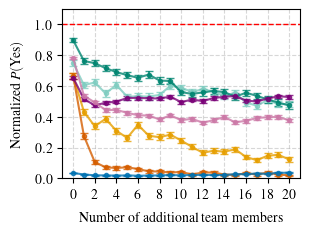

In [15]:
process_and_plot_together(dfs_humans_costs, family_colors, ylabel = True, xlabel = True, file_name = "overview_humans_withcosts")

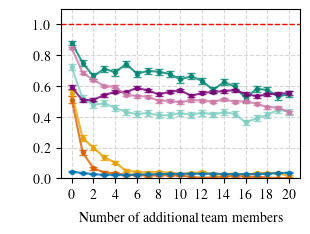

In [16]:
process_and_plot_together(dfs_agents_costs, family_colors, ylabel = False, xlabel = True, file_name = "overview_agents_withcosts")

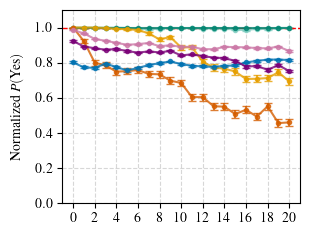

In [17]:
process_and_plot_together(dfs_humans_wocosts, family_colors, ylabel = True, xlabel = False, file_name = "overview_humans_wocosts")

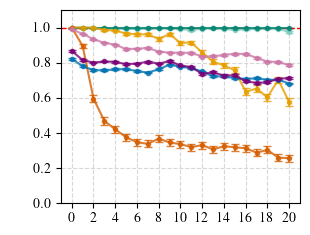

In [18]:
process_and_plot_together(dfs_agents_wocosts, family_colors, ylabel = False, xlabel = False, file_name = "overview_agents_wocosts")

In [19]:
all_dfs = []

for model, df_or in dfs_humans_costs.items():

    df = df_or.copy()
    df["model"] = model
    df["costs"] = 1
    df["humans"] = 1
    df["round"] = df.index
    all_dfs.append(df)

for model, df_or in dfs_agents_costs.items():

    df = df_or.copy()
    df["model"] = model
    df["costs"] = 1
    df["humans"] = 0
    df["round"] = df.index + 500
    all_dfs.append(df)

for model, df_or in dfs_humans_wocosts.items():

    df = df_or.copy()
    df["model"] = model
    df["costs"] = 0
    df["humans"] = 1
    df["round"] = df.index + 1000
    all_dfs.append(df)

for model, df_or in dfs_agents_wocosts.items():

    df = df_or.copy()
    df["model"] = model
    df["costs"] = 0
    df["humans"] = 0
    df["round"] = df.index + 1500
    all_dfs.append(df)
    

In [20]:
# transform to one dataframe in long format
df_all = pd.concat(all_dfs, ignore_index=True)
df_all = df_all.melt(
        id_vars=["model", "costs", "humans", "round"],
        var_name="bystanders",
        value_name="help_prob"
    )

In [21]:
df_all["bystanders"] = df_all["bystanders"].astype(int)
df_all["log_bystanders"] = np.log1p(df_all["bystanders"]) # log transformation

results = {}

# analyse results per model
for model, group in df_all.groupby("model"):
    group = group.copy().reset_index(drop=True)
    
    formula = "help_prob ~ log_bystanders * humans + log_bystanders * costs"
    
    model_fit = smf.ols(formula, data=group).fit(
        cov_type="cluster",
        cov_kwds={"groups": group["round"]},
        disp=False
    )
    
    results[model] = model_fit
    
    print(f"\n{'='*50}")
    print(f"Model: {model}")
    print(f"{'='*50}")
    print(model_fit.summary())





Model: gemma12
                            OLS Regression Results                            
Dep. Variable:              help_prob   R-squared:                       0.574
Model:                            OLS   Adj. R-squared:                  0.574
Method:                 Least Squares   F-statistic:                     7331.
Date:                Wed, 06 May 2026   Prob (F-statistic):               0.00
Time:                        08:21:29   Log-Likelihood:                -10971.
No. Observations:               42000   AIC:                         2.195e+04
Df Residuals:                   41994   BIC:                         2.201e+04
Df Model:                           5                                         
Covariance Type:              cluster                                         
                            coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------
Intercept     

In [22]:
rows = []

for model_name, res in results.items():
    for var, label in [
        ("log_bystanders", "Bystander effect"),
        ("humans", "Humans"),
        ("log_bystanders:humans", "Interaction effect - Humans"),
        ("costs", "Costs"),
        ("log_bystanders:costs", "Interaction effect - Costs")
    ]:
        coef = res.params[var]
        se = res.bse[var]

        rows.append({
            "model": model_name,
            "effect": label,
            "coef": coef,
            "ci_low": coef - 1.96 * se,
            "ci_high": coef + 1.96 * se
        })

coef_df = pd.DataFrame(rows)

In [23]:
coef_df

,model,effect,coef,ci_low,ci_high
0,gemma12,Bystander effect,-0.130943,-0.143245,-0.118641
1,gemma12,Humans,0.094875,0.072398,0.117352
2,gemma12,Interaction effect - Humans,-0.000794,-0.013979,0.012392
3,gemma12,Costs,-0.665182,-0.687659,-0.642705
4,gemma12,Interaction effect - Costs,-0.011480,-0.024666,0.001705
5,gemma27,Bystander effect,-0.200703,-0.211562,-0.189845
6,gemma27,Humans,0.136887,0.112837,0.160938
7,gemma27,Interaction effect - Humans,0.004860,-0.006960,0.016681
8,gemma27,Costs,-0.625939,-0.649989,-0.601889
9,gemma27,Interaction effect - Costs,0.073758,0.061937,0.085578


/tmp/ipykernel_889/675025528.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  coef_df_filter["model"] = pd.Categorical(


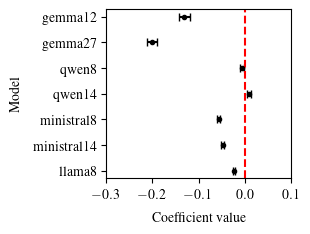

In [24]:
plot_coefficients(coef_df, range = np.arange(-0.3, 0.2, 0.1))

/tmp/ipykernel_889/675025528.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  coef_df_filter["model"] = pd.Categorical(


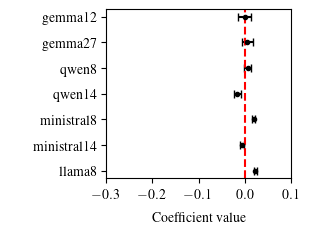

In [25]:
plot_coefficients(coef_df, "Interaction effect - Humans", np.arange(-0.3, 0.2, 0.1), True, False)

#### Comparing activation of processes

In [26]:
dfs_humans_no = df_dicts_activated_wocost["humans"][None]
dfs_agents_no = df_dicts_activated_wocost["agents"][None]
dfs_humans_p = df_dicts_activated_wocost["humans"]["p"]
dfs_agents_p = df_dicts_activated_wocost["agents"]["p"]
dfs_humans_e= df_dicts_activated_wocost["humans"]["e"]
dfs_agents_e = df_dicts_activated_wocost["agents"]["e"]
dfs_humans_r = df_dicts_activated_wocost["humans"]["r"]
dfs_agents_r = df_dicts_activated_wocost["agents"]["r"]
dfs_humans_all = df_dicts_activated_wocost["humans"]["all"]
dfs_agents_all = df_dicts_activated_wocost["agents"]["all"]

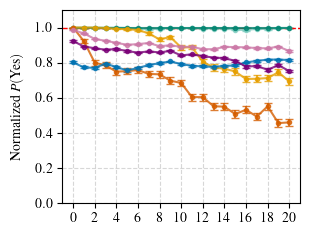

In [27]:
process_and_plot_together(dfs_humans_no, family_colors, ylabel = True, xlabel = False, file_name = "overview_humans_noprocess")

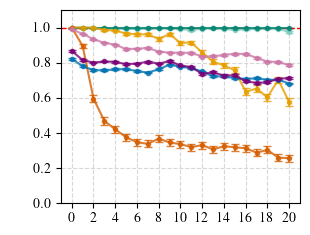

In [28]:
process_and_plot_together(dfs_agents_no, family_colors, ylabel = False, xlabel = False, file_name = "overview_agents_noprocess")

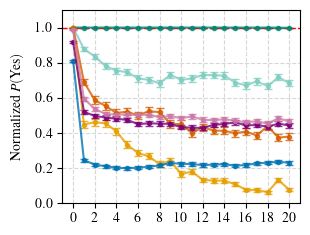

In [29]:
process_and_plot_together(dfs_humans_r, family_colors, ylabel = True, xlabel = False, file_name = "overview_humans_resp")

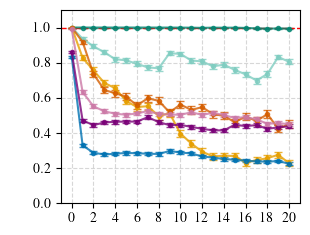

In [30]:
process_and_plot_together(dfs_agents_r, family_colors, ylabel = False, xlabel = False, file_name = "overview_agents_resp")

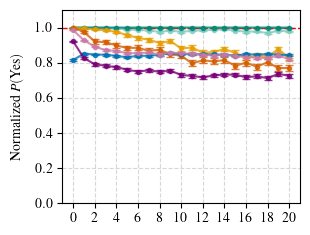

In [31]:
process_and_plot_together(dfs_humans_e, family_colors, ylabel = True, xlabel = False, file_name = "overview_humans_eval")

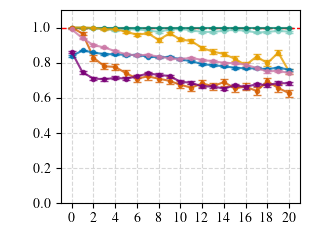

In [32]:
process_and_plot_together(dfs_agents_e, family_colors, ylabel = False, xlabel = False, file_name = "overview_agents_eval")

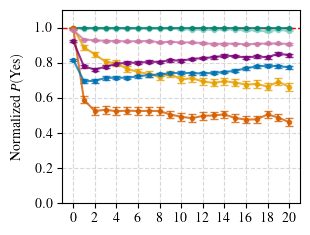

In [33]:
process_and_plot_together(dfs_humans_p, family_colors, ylabel = True, xlabel = False, file_name = "overview_humans_plural")

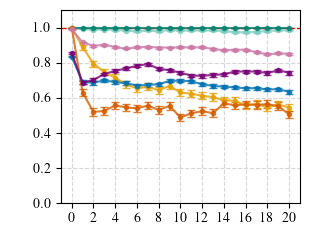

In [34]:
process_and_plot_together(dfs_agents_p, family_colors, ylabel = False, xlabel = False, file_name = "overview_agents_plural")

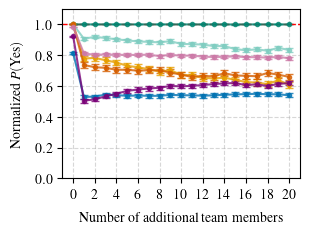

In [35]:
process_and_plot_together(dfs_humans_all, family_colors, ylabel = True, xlabel = True, file_name = "overview_humans_all")

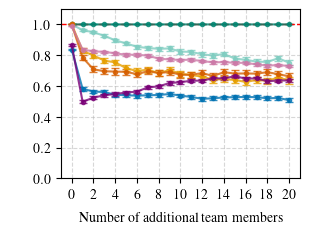

In [36]:
process_and_plot_together(dfs_agents_all, family_colors, ylabel = False, xlabel = True, file_name = "overview_agents_all")

In [37]:
all_dfs_act = []

for model, df_or in dfs_humans_no.items():

    df = df_or.copy()
    df["model"] = model
    df["process"] = "no"
    df["humans"] = 1
    df["round"] = df.index 
    
    all_dfs_act.append(df)
                  
for model, df_or in dfs_agents_no.items():

    df = df_or.copy()
    df["model"] = model
    df["process"] = "no"
    df["humans"] = 0
    df["round"] = df.index + 500
    
    all_dfs_act.append(df)

for model, df_or in dfs_humans_p.items():

    df = df_or.copy()
    df["model"] = model
    df["process"] = "p"
    df["humans"] = 1
    df["round"] = df.index + 1000
    
    all_dfs_act.append(df)
    
for model, df_or in dfs_agents_p.items():

    df = df_or.copy()
    df["model"] = model
    df["process"] = "p"
    df["humans"] = 0
    df["round"] = df.index + 1500
    
    all_dfs_act.append(df)

for model, df_or in dfs_humans_e.items():

    df = df_or.copy()
    df["model"] = model
    df["process"] = "e"
    df["humans"] = 1
    df["round"] = df.index  + 2000
    
    all_dfs_act.append(df)

for model, df_or in dfs_agents_e.items():

    df = df_or.copy()
    df["model"] = model
    df["process"] = "e"
    df["humans"] = 0
    df["round"] = df.index + 2500
    
    all_dfs_act.append(df) 


for model, df_or in dfs_humans_r.items():

    df = df_or.copy()
    df["model"] = model
    df["process"] = "r"
    df["humans"] = 1
    df["round"] = df.index + 3000
    
    all_dfs_act.append(df) 

for model, df_or in dfs_agents_r.items():

    df = df_or.copy()
    df["model"] = model
    df["process"] = "r"
    df["humans"] = 0
    df["round"] = df.index  + 3500
    
    all_dfs_act.append(df)


for model, df_or in dfs_humans_all.items():

    df = df_or.copy()
    df["model"] = model
    df["process"] = "all"
    df["humans"] = 1
    df["round"] = df.index+ 4000
    
    all_dfs_act.append(df) 

for model, df_or in dfs_agents_all.items():

    df = df_or.copy()
    df["model"] = model
    df["process"] = "all"
    df["humans"] = 0
    df["round"] = df.index + 4500
    
    all_dfs_act.append(df)

In [38]:
# transform to one dataframe in long format
df_all_act = pd.concat(all_dfs_act, ignore_index=True)
df_all_act = df_all_act.melt(
        id_vars=["model", "process", "humans", "round"],
        var_name="bystanders",
        value_name="help_prob"
    )

In [39]:
df_all_act["bystanders"] = df_all_act["bystanders"].astype(int)
df_all_act["log_bystanders"] = np.log1p(df_all_act["bystanders"]) # log transformation

results = {}

# analyse results per model
for model, group in df_all_act.groupby("model"):
    group = group.copy().reset_index(drop=True)
    
    formula = "help_prob ~ log_bystanders * C(process, Treatment(reference='no'))"
    
    model_fit = smf.ols(formula, data=group).fit(
        cov_type="cluster",
        cov_kwds={"groups": group["round"]},
        disp=False
    )
    
    results[model] = model_fit
    
    print(f"\n{'='*50}")
    print(f"Model: {model}")
    print(f"{'='*50}")
    print(model_fit.summary())


Model: gemma12
                            OLS Regression Results                            
Dep. Variable:              help_prob   R-squared:                       0.278
Model:                            OLS   Adj. R-squared:                  0.278
Method:                 Least Squares   F-statistic:                     907.7
Date:                Wed, 06 May 2026   Prob (F-statistic):               0.00
Time:                        08:30:54   Log-Likelihood:                -43925.
No. Observations:              105000   AIC:                         8.787e+04
Df Residuals:                  104990   BIC:                         8.797e+04
Df Model:                           9                                         
Covariance Type:              cluster                                         
                                                                  coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------

In [40]:
rows = []

for model_name, res in results.items():
    for var, label in [
        ("log_bystanders", "Bystander effect"),
        #("humans", "Humans"),
        #("log_bystanders:humans", "Interaction effect - Humans"),
        ("log_bystanders:C(process, Treatment(reference='no'))[T.all]", "Interaction effect - all processes"),
        ("log_bystanders:C(process, Treatment(reference='no'))[T.e]", "Interaction effect - evaluation apprehension"),
        ("log_bystanders:C(process, Treatment(reference='no'))[T.p]", "Interaction effect - pluralistic ignorance"),
        ("log_bystanders:C(process, Treatment(reference='no'))[T.r]", "Interaction effect - responsibility diffusion"),
    ]:
        coef = res.params[var]
        se = res.bse[var]

        rows.append({
            "model": model_name,
            "effect": label,
            "coef": coef,
            "ci_low": coef - 1.96 * se,
            "ci_high": coef + 1.96 * se
        })

coef_df = pd.DataFrame(rows)

/tmp/ipykernel_889/675025528.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  coef_df_filter["model"] = pd.Categorical(


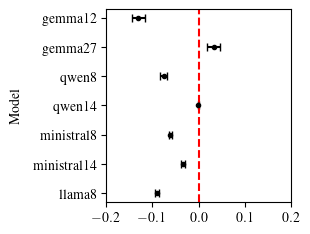

In [41]:
plot_coefficients(coef_df, "Interaction effect - responsibility diffusion", np.arange(-0.2, 0.21, 0.1), xlabel = False, ylabel = True)

/tmp/ipykernel_889/675025528.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  coef_df_filter["model"] = pd.Categorical(


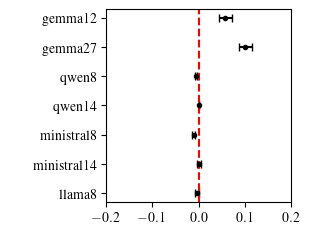

In [42]:
plot_coefficients(coef_df, "Interaction effect - evaluation apprehension", np.arange(-0.2, 0.21, 0.1),  xlabel = False, ylabel = False)

/tmp/ipykernel_889/675025528.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  coef_df_filter["model"] = pd.Categorical(


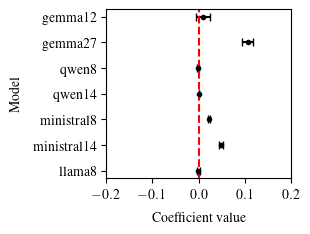

In [43]:
plot_coefficients(coef_df, "Interaction effect - pluralistic ignorance", np.arange(-0.2, 0.21, 0.1), xlabel = True, ylabel = True)

/tmp/ipykernel_889/675025528.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  coef_df_filter["model"] = pd.Categorical(


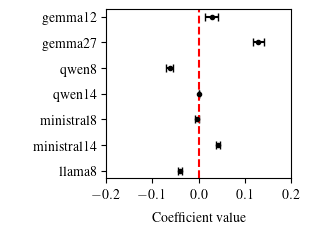

In [44]:
plot_coefficients(coef_df, "Interaction effect - all processes", np.arange(-0.2, 0.21, 0.1), xlabel = True, ylabel = False)

### Calculate Summary Score

In [29]:
def calculate_area_under_curve(df_dict):
    """
    Calculate the area between the actual curve and a horizontal baseline
    set at the first column mean for each model.
    """
    area_scores = {}
    
    for model_name, df in df_dict.items():
        
        # Calculate average prob for each number of bystanders
        column_means = df.mean(axis=0)
        num_byst = column_means.index.astype(int)

        # Baseline: horizontal line at the first column mean
        baseline = column_means.iloc[0]
        baseline_curve = np.full_like(column_means, fill_value=baseline, dtype=float)

        # maximum curve would be starting at baseline, then going down to 0
        max_traj = [baseline] + [0] * (len(num_byst) -1)

        # Area between the actual curve and the baseline
        actual_area = np.trapezoid(column_means, num_byst)
        baseline_area = np.trapezoid(baseline_curve, num_byst)
        area_between = baseline_area - actual_area

        # area between the baseline and the maximum curve
        maximum_area = np.trapezoid(max_traj, num_byst)
        max_area_between = baseline_area - maximum_area

        # normalize actual area by maximum area
        normalized_area = area_between / max_area_between

        area_scores[model_name] = normalized_area

    return area_scores

In [29]:
scores_humans_withcost = calculate_area_under_curve(df_dicts_activated_withcost["humans"][None])
scores_humans_wocost = calculate_area_under_curve(df_dicts_activated_wocost["humans"][None])
scores_agents_withcost = calculate_area_under_curve(df_dicts_activated_withcost["agents"][None])
scores_agents_wocost = calculate_area_under_curve(df_dicts_activated_wocost["agents"][None])

In [35]:
summary_scores = pd.DataFrame([scores_humans_withcost, scores_humans_wocost, scores_agents_withcost, scores_agents_wocost],
                              index = ["humans_withcost", "humans_wocost", "agents_withcost", "agents_wocost"]
                             )

In [39]:
summary_scores.to_csv("results/summary_sharedtask.csv", index_label="Experiment")